In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import torch
import gc
from IPython.display import display

ds_name = 'house_price_traj'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
proj_name = 'SurvSurfBenchmark_HousePrice'
g_resol = 0.01
t_resol = 1
g_max = 1
split='test'
col_traj_id = 'traj_id'
n_g_steps = 100
equal_steps = True

In [2]:
DEVICE = 'cpu'
if DEVICE == 'gpu':
    assert torch.cuda.is_available()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
else:
    device = 'cpu'

## Import and instantiate model

In [3]:
from dataset_PropertyPrice import DatasetHousePrice, DataModuleHousePrice

In [4]:
ds = DatasetHousePrice(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    t_resol=t_resol,
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False,
)
df_obs = ds._get_df_Xy_trans_obs()
df_true_prob = ds._get_df_Xy_true_prob()
df_true_prob.loc[
    df_true_prob[ds.colname_g] == 6,:
].head()

,traj_id,duration,g_max_by_time,event_observed,weight,feat__is_new_build,feat__long,feat__lat,feat__frac_properties_n_beds__1,feat__frac_properties_n_beds__2,...,feat__deprived_3_dim,feat__deprived_4_dim,feat__soc_grade_AB,feat__soc_grade_C1,feat__soc_grade_C2,feat__soc_grade_DE,feat__prop_type_Detached,feat__prop_type_SemiD,feat__prop_type_Terraced,is_t_trans


In [5]:
df_true_prob['g_max_by_time'].value_counts()

g_max_by_time
1.000000    1400
0.500000    1400
0.333333    1400
0.250000    1400
0.200000    1400
0.166667    1400
0.142857    1400
0.125000    1400
0.111111    1400
0.100000    1400
Name: count, dtype: int64

In [6]:
from model_eval_utils import (
    get_all_grades_start_end_time, 
)
def pred_by_counting(run_id, proj_name, split='val'):
    ds_train = DatasetHousePrice(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        split='train', 
        mode='true_probs_grid', 
        separate_g_from_feats=False,
        n_steps=n_g_steps,
        equal_steps=equal_steps
    )
    
    ds_split = DatasetHousePrice(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        split=split, 
        mode='true_probs_grid', 
        separate_g_from_feats=False,
        n_steps=n_g_steps,
        equal_steps=equal_steps
    )
    obs_full_traj = ds_train._get_df_Xy_full_traj_obs(g0_as_gres=False).rename(columns={col_traj_id:'subject'})
    out_dfs = dict()
    for flag, pred_holder in [
        ('obs', ds_split._get_df_Xy_trans_obs()),
        ('true_prob', ds_split._get_df_Xy_true_prob())
    ]:
        gs = pred_holder[ds_split.colname_g].unique()
        ts = pred_holder['duration'].unique()
        pred_holder['pred'] = np.nan
        pred_holder = pred_holder.rename(
            columns={
                ds_split.colname_g:'g',
                'duration':'t',
                'event_observed':'truth',
                ds_split.colname_traj_id:'subj'
            }
        )
        obs_trans_time_all_g = get_all_grades_start_end_time(obs_full_traj, gs=gs)
        assert all(obs_trans_time_all_g['g'].unique() == gs)
        for g, obs_trans_time in obs_trans_time_all_g.groupby('g'):
            for t in ts:
                event_observed =  obs_trans_time['event_observed'].astype(bool)
                time_happened = obs_trans_time['t_observed_or_censored'].astype(float)
                time_alive = obs_trans_time ['t_uncensored_alive'].astype(float)
                missing_exact_t = obs_trans_time['missing_exact_t'].astype(bool)
                
                is_case = (time_happened <= t) & event_observed 
                is_control_exact_t = (time_happened >= t) & ~event_observed
                is_control_inexact_t = (time_alive >= t) & missing_exact_t
                is_control = is_control_exact_t | is_control_inexact_t

                pred = sum(is_case)/(sum(is_case) + sum(is_control))

                selector = (pred_holder['g'] == g) & (pred_holder['t'] == t)
                pred_holder.loc[selector, 'pred'] = pred
        out_dfs[flag] = pred_holder
    return out_dfs, f'Count_from_train_intvl_imputed'

In [7]:
import pickle
def pred_from_sksurv_joint(run_id, proj_name, split='val'):

    if 'more_g' in run_id:
        path_pickle = f'./sksurv_models/more_g/{proj_name}/Joint/{run_id}.pickle'
    else:
        path_pickle = f'./sksurv_models/{proj_name}/Joint/{run_id}.pickle'
    with open(path_pickle, 'rb') as f:
        model = pickle.load(f)
    
    ds = DatasetHousePrice(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        t_resol=t_resol,
        split=split, 
        mode='first_cross_obs_only', 
        separate_g_from_feats=False,
        n_steps=n_g_steps,
        equal_steps=equal_steps
    )
    df_obs = ds._get_df_Xy_trans_obs()
    df_true_prob = ds._get_df_Xy_true_prob()
    assert (
        df_true_prob.groupby([col_traj_id,ds.colname_g]).apply(
            lambda x: tuple(x['duration']),
            include_groups=False
        )
    ).nunique() == 1


    cols_X = np.r_[[ds.colname_g], df_obs.columns[df_obs.columns.str.startswith('feat')]]      

    df_val_results_obs = []
    df_val_results_grid = []
    for g, df_obs_g in df_obs.groupby(ds.colname_g):
        if g > ds.g_max:
            continue

        curvs = model.predict_survival_function(df_obs_g[cols_X])
                
        
        for subj, curv in zip(df_obs_g[col_traj_id], curvs):
            obs_g_subj = df_obs_g.loc[df_obs_g[col_traj_id] == subj,:]
            assert obs_g_subj.shape[0] == 1
            obs_g_subj = obs_g_subj.iloc[0,:]
            t = obs_g_subj['duration']
            truth = obs_g_subj['event_observed']
            if t > curv.x.max():
                pred = curv(curv.x.max())
            else:
                pred = curv(t)
            row = {
                'subj':subj,
                'g':g,
                't':t,
                'pred':1-pred,
                'truth':truth
            }
            df_val_results_obs.append(row)

    for g, df_true_prob_g in df_true_prob.groupby(ds.colname_g):   
        df_true_prob_g_tless = df_true_prob_g.drop(columns=['duration','event_observed']).drop_duplicates()
        assert df_true_prob_g_tless[col_traj_id].value_counts().max() == 1
        curvs = model.predict_survival_function(df_true_prob_g_tless[cols_X])

        for subj, curv in zip(df_true_prob_g_tless[col_traj_id], curvs):
            df_val_subj_g = pd.DataFrame()
            df_true_prob_subj_g = df_true_prob_g.loc[
                df_true_prob_g[col_traj_id] == subj,:
            ].sort_values('duration')
            t_grid = df_true_prob_subj_g['duration']
            t_grid_in_range = t_grid[t_grid <= curv.x.max()]
            t_grid_extrap = t_grid[t_grid > curv.x.max()]
            pred_prob_at_time_grid = curv(t_grid_in_range)
            pred_prob_at_time_grid = np.r_[pred_prob_at_time_grid, [pred_prob_at_time_grid[-1]]*t_grid_extrap.size]

            df_val_subj_g['t'] = t_grid
            df_val_subj_g['subj'] = subj
            df_val_subj_g['g'] = g
            df_val_subj_g['pred'] = 1-pred_prob_at_time_grid
            df_val_subj_g['truth'] = df_true_prob_subj_g['event_observed']
            df_val_results_grid.append(df_val_subj_g)

    out_dfs = dict()
    out_dfs['obs'] = pd.DataFrame(df_val_results_obs)
    out_dfs['true_prob'] = pd.concat(df_val_results_grid)
    return out_dfs, f'Joint_{model.__class__.__name__}'

In [8]:
def pred_from_DeepHit(run_id, proj_name, split='val'):
    import wandb
    from model_factory_deephit import LitModelDeepHit
    torch.set_float32_matmul_precision('medium')

    api = wandb.Api()
    # artifact = api.artifact(f'yichenchen-wings/{proj_name}/model-{run_id}:v0', type='model')
    # checkpoint_dir = artifact.download()
    checkpoint_dir = f'/home/yc366/repos/survsurf_benchmark/runtime_results/{proj_name}/{run_id}/checkpoints/'
    os.listdir(checkpoint_dir)[0]
    #path_checkpoint = os.path.join(checkpoint_dir, 'model.ckpt')
    path_checkpoint = os.path.join(checkpoint_dir, os.listdir(checkpoint_dir)[0])
    model_lit = LitModelDeepHit.load_from_checkpoint(path_checkpoint)
    
    datamodule = DataModuleHousePrice(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        t_resol=t_resol,
        separate_g_from_feats=False, 
        train_mode='first_cross_obs_only',
        eval_mode='true_probs_grid',
        batch_size=100, 
        num_workers=4,
        n_steps=n_g_steps,
        equal_steps=equal_steps
    )
    datamodule.setup(stage=split)
    if 'val' in split:
        dataloader_obs, dataloader_true_prob = datamodule.val_dataloader()
    if 'test' in split:
        dataloader_obs, dataloader_true_prob = datamodule.test_dataloader()

    with torch.no_grad():
        torch.cuda.empty_cache()
    gc.collect()

    model_loaded_core = model_lit.model
    model_loaded_core = model_loaded_core.to(device)
    model_loaded_core.eval()

    t_size = model_lit.loss_brier.t_size
    t_res = model_lit.loss_brier.t_res

    out_dfs = dict()
    for key, dataloader in [
        ('obs', dataloader_obs),
        ('true_prob', dataloader_true_prob)
    ]:
        
        out_dfs = dict()
    for key, dataloader in [
        ('obs', dataloader_obs),
        ('true_prob', dataloader_true_prob)
    ]:
        subjs = []
        g = []
        t = []
        pred = []
        truth = []
        with torch.no_grad():
            for batch_, (subj, xs, ts, ys, weight, _) in enumerate(dataloader):
                xs, ts, ys = xs.to(device), ts.to(device), ys.to(device)
                out = model_loaded_core.forward_cif(xs)
                assert out.dim() == 3, f'found output with n dim = {out.dim()}, expecting a 3d tensor.'
                assert out.shape[1] == 1, f'found output with second dim = {out.shape[1]}, expecting 1.'
                out = out.reshape(out.shape[0], out.shape[-1])

                t_matrix = ts.repeat(1, t_size)
                
                t_matrix_ref = torch.linspace(0, t_size-1, steps=t_size)*t_res
                t_matrix_ref = t_matrix_ref.repeat(xs.shape[0], 1)

                selector_where_t = torch.logical_and(t_matrix_ref >= t_matrix,  t_matrix_ref < (t_matrix + t_res))
                assert torch.all(selector_where_t.sum(dim=-1) == 1)
                out = out[selector_where_t].reshape(xs.shape[0])

                subjs += list(subj)
                g += list(datamodule.g_max*xs.cpu().numpy()[:,-1])
                t += list(ts.cpu().numpy()[:,0])
                truth += list(ys.cpu().numpy()[:,0])
                pred += list(out.cpu().numpy())


        pred = np.array(pred)
        truth = np.array(truth)
        df_val_results = pd.DataFrame()
        df_val_results['subj'] = subjs
        df_val_results['g'] = g
        df_val_results['t'] = t
        df_val_results['pred'] = pred
        df_val_results['truth'] = truth
        for col in ['pred', 'truth']:
            df_val_results[col] = df_val_results[col].astype(float)
        out_dfs[key] = df_val_results
    return out_dfs, model_loaded_core.__class__.__name__


In [9]:

def pred_from_SurvSurf(run_id, proj_name, split='val'):
    import wandb
    from model_factory_survsurf import LitModelSurvSurf
    torch.set_float32_matmul_precision('medium')

    api = wandb.Api()
    # artifact = api.artifact(f'yichenchen-wings/{proj_name}/model-{run_id}:v0', type='model')
    # checkpoint_dir = artifact.download()
    checkpoint_dir = f'/home/yc366/repos/survsurf_benchmark/runtime_results/{proj_name}/{run_id}/checkpoints/'
    os.listdir(checkpoint_dir)[0]
    #path_checkpoint = os.path.join(checkpoint_dir, 'model.ckpt')
    path_checkpoint = os.path.join(checkpoint_dir, os.listdir(checkpoint_dir)[0])
    model_lit = LitModelSurvSurf.load_from_checkpoint(path_checkpoint)
    
    datamodule = DataModuleHousePrice(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        t_resol=t_resol,
        separate_g_from_feats=True, 
        train_mode='first_cross_obs_only',
        eval_mode='true_probs_grid',
        batch_size=100, 
        num_workers=4,
        n_steps=n_g_steps,
        equal_steps=equal_steps
    )
    datamodule.setup(stage=split)
    if 'val' in split:
        dataloader_obs, dataloader_true_prob = datamodule.val_dataloader()
    if 'test' in split:
        dataloader_obs, dataloader_true_prob = datamodule.test_dataloader()

    with torch.no_grad():
        torch.cuda.empty_cache()
    gc.collect()

    model_loaded_core = model_lit.model
    model_loaded_core = model_loaded_core.to(device)
    model_loaded_core.eval()


    out_dfs = dict()
    for key, dataloader in [
        ('obs', dataloader_obs),
        ('true_prob', dataloader_true_prob)
    ]:
        
        subjs = []
        g = []
        t = []
        pred = []
        truth = []
        with torch.no_grad():
            for batch_, (subj, xs, gs, ts, ys, weight, _) in enumerate(dataloader):
                xs, gs, ts, ys = xs.to(device), gs.to(device), ts.to(device), ys.to(device)
                out = model_loaded_core(ts, gs, xs)
                subjs += list(subj)
                g += list(datamodule.g_max*gs.cpu().numpy()[:,0])
                t += list(ts.cpu().numpy()[:,0])
                truth += list(ys.cpu().numpy()[:,0])
                pred += list(out.cpu().numpy()[:,0])


        pred = np.array(pred)
        truth = np.array(truth)
        df_val_results = pd.DataFrame()
        df_val_results['subj'] = subjs
        df_val_results['g'] = g
        df_val_results['t'] = t
        df_val_results['pred'] = pred
        df_val_results['truth'] = truth
        for col in ['pred', 'truth']:
            df_val_results[col] = df_val_results[col].astype(float)
        out_dfs[key] = df_val_results
    return out_dfs, model_loaded_core.__class__.__name__


In [10]:


ds_train = DatasetHousePrice(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    t_resol=t_resol,
    split='train', 
    mode='true_probs_grid', 
    separate_g_from_feats=False,
    n_steps=n_g_steps,
    equal_steps=equal_steps
)
ds_val = DatasetHousePrice(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    t_resol=t_resol,
    split='val', 
    mode='true_probs_grid', 
    separate_g_from_feats=False,
    n_steps=n_g_steps,
    equal_steps=equal_steps
)
ds_test = DatasetHousePrice(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    t_resol=t_resol,
    split='test', 
    mode='true_probs_grid', 
    separate_g_from_feats=False,
    n_steps=n_g_steps,
    equal_steps=equal_steps
)

In [11]:
ds_test._get_df_Xy_trans_obs()['g_max_by_time'].value_counts()

g_max_by_time
0.010000    8
0.014897    1
0.299504    1
0.069020    1
0.135840    1
           ..
0.178515    1
0.041112    1
0.083945    1
0.170352    1
0.504031    1
Name: count, Length: 1071, dtype: int64

## Define metrics

In [12]:
from model_eval_utils import (
    get_all_grades_start_end_time, 
    get_integrated_brier_intrvl_imputed, 
)

In [13]:
if split == 'val':
    gs = ds_val._get_df_Xy_true_prob()[ds_val.colname_g].unique()
if split == 'test':
    gs = ds_test._get_df_Xy_true_prob()[ds_val.colname_g].unique()

In [14]:
gs

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
       0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
       0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
       0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
       0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99,
       1.  ])

/tmp/ipykernel_8832/2375502650.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df_max_g_by_t_obs.groupby(col_traj_id).apply(lambda df: _get_last_obs_time(df, g))
/tmp/ipykernel_8832/2375502650.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df_max_g_by_t_obs.groupby(col_traj_id).apply(lambda df: _get_last_obs_time(df, g))
/tmp/ipykernel_8832/2375502650.py:10: DeprecationWarning: DataFram

min censoring S(t) for g = 0.94688740391781
min censoring S(t) for g = 0.9414455222860987
min censoring S(t) for g = 0.924328330971806
min censoring S(t) for g = 0.9194116909134453
min censoring S(t) for g = 0.9194116909134453
min censoring S(t) for g = 0.911128702707018
min censoring S(t) for g = 0.8950025309776901
min censoring S(t) for g = 0.890267067850824
min censoring S(t) for g = 0.8724297791109898
min censoring S(t) for g = 0.857808050969465
min censoring S(t) for g = 0.857808050969465
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0
min c

[Text(0, 0.5, 'S(t) for censoring'), Text(0.5, 0, 't')]

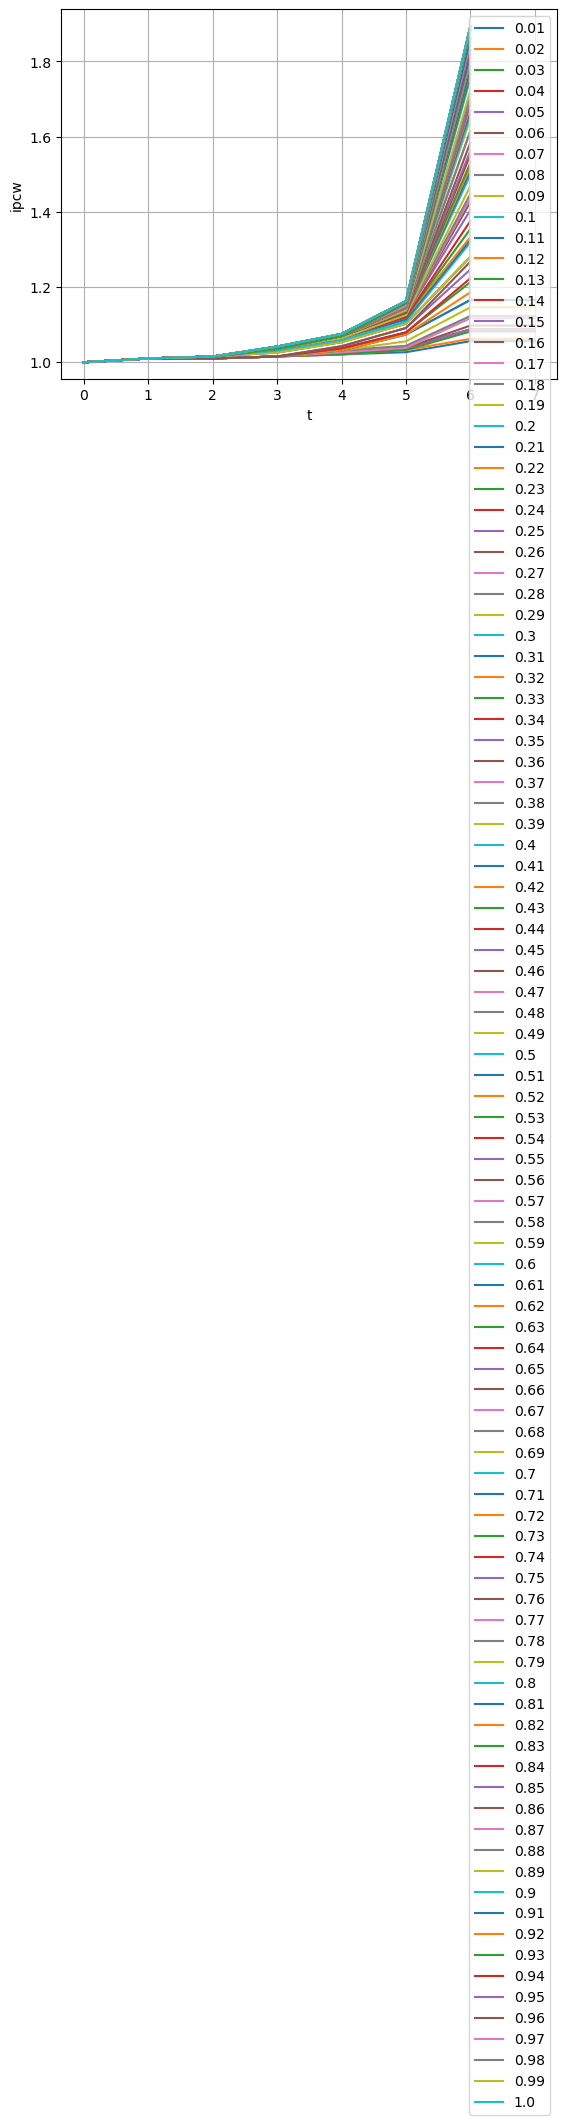

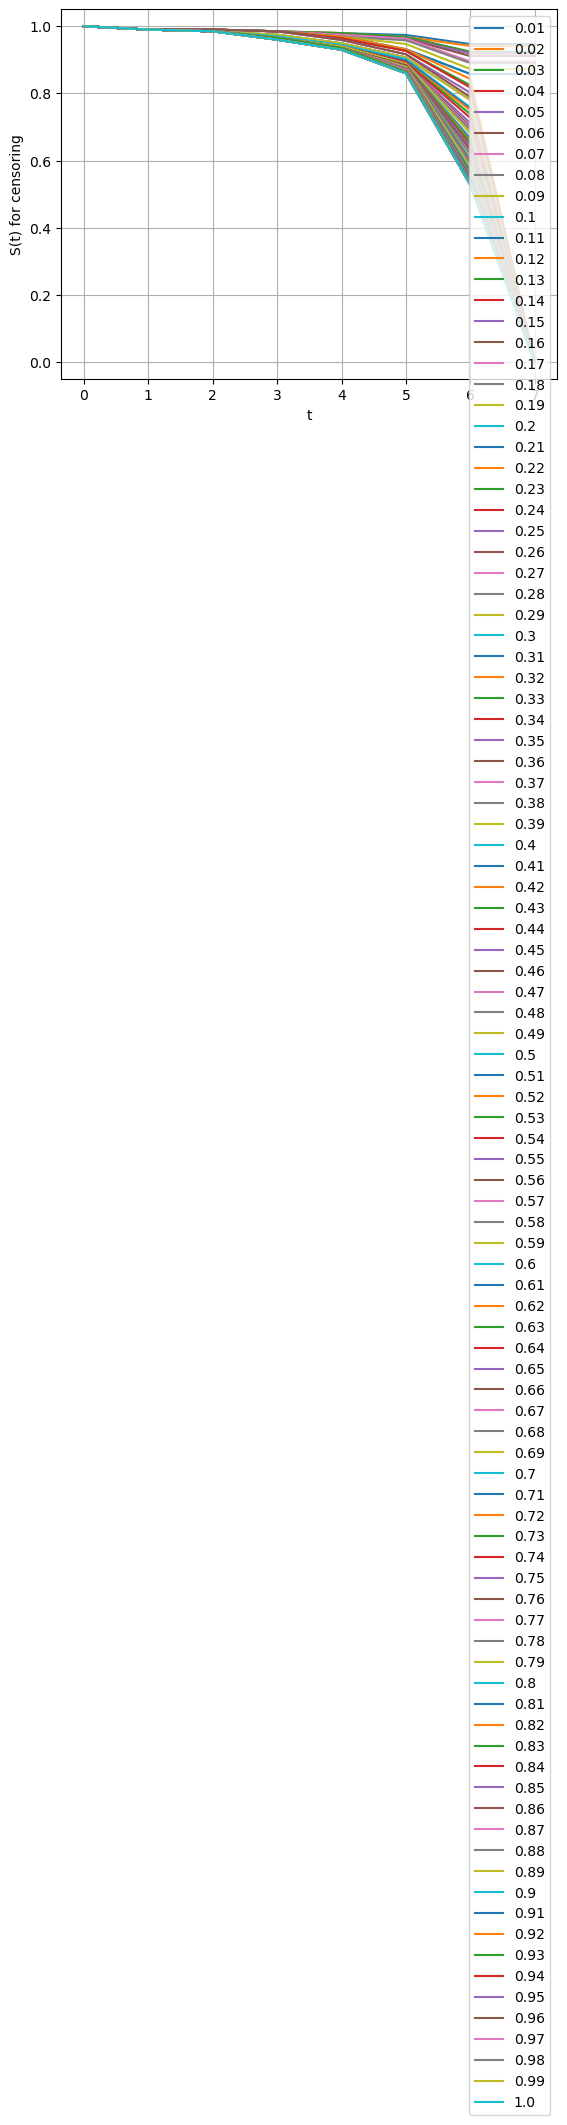

In [15]:
from typing import Literal
from sksurv.nonparametric import kaplan_meier_estimator
from model_eval_utils import _get_last_obs_time

def get_pre_censoring_t(df_dir, ds_name, gs, split: Literal['train', 'tune', 'val', 'test']):
    path_max_g_by_t_obs = os.path.join(df_dir,f'{ds_name}__df_state_history_sampled_max_{split}.csv')
    df_max_g_by_t_obs = pd.read_csv(path_max_g_by_t_obs, index_col=0)
    df_out = []
    for g in gs:
        df = df_max_g_by_t_obs.groupby(col_traj_id).apply(lambda df: _get_last_obs_time(df, g))
        df_out.append(df)
    df_out = pd.concat(df_out)
    return df_out

class IPCW:
    def __init__(self, time, S_censor):
        self.time = time
        self.S_censor = S_censor
    def __call__(self,t):
        S_censor = self.S_censor
        # percentile  = np.percentile(S_censor, 10)
        # S_censor[S_censor <= percentile] = percentile
        S = np.interp(t, self.time, S_censor)
        return 1/S

def get_train_ipcw(df_event_g_at_t_obs):
    df_event_g_at_t_obs = df_event_g_at_t_obs
    g_to_censor_curv = dict()
    for g, df_event_t in df_event_g_at_t_obs.groupby('g'):
        df_event_t = df_event_t.sort_values('duration')
        time, S_censor = kaplan_meier_estimator(df_event_t['event_observed'].astype(bool), df_event_t['duration'], reverse=True)
        if 0 not in time:
            time = np.r_[[0.], time]
            S_censor = np.r_[[1.], S_censor]
        g_to_censor_curv[g] = IPCW(time, S_censor)
    return g_to_censor_curv

df_last_obs_time_split = get_pre_censoring_t(df_dir=ds_df_dir,ds_name=ds_name, gs=gs, split=split).rename(
    columns={col_traj_id:'subject'}
)
df_last_obs_time_split = df_last_obs_time_split.loc[df_last_obs_time_split['g'] <= g_max, :]
df_train_obs_censor_less = df_last_obs_time_split.copy()
df_train_obs_censor_less['event_observed'] = True
df_train_obs_censor_less['duration'] = df_train_obs_censor_less['duration'].astype(float)
dict_ipcw = get_train_ipcw(df_last_obs_time_split)

fig, ax = plt.subplots(1,1,)
for g in gs:
    x = np.arange(0, 8, 1)
    y = dict_ipcw[g](x)
    ax.plot(x, y, label=g),
ax.legend()
ax.grid()
ax.set(ylabel='ipcw', xlabel='t')


fig, ax = plt.subplots(1,1,)
for g in gs:
    x = np.arange(0, 8, 1)
    y = 1/dict_ipcw[g](x)
    print(f'min censoring S(t) for g = {y.min()}')
    ax.plot(x, y, label=g),
ax.legend()
ax.grid()
ax.set(ylabel='S(t) for censoring', xlabel='t')

In [16]:
df_last_obs_time_split

,g,duration,event_observed
traj_id,,,
E06000001SemiNew,0.01,4.0,True
E06000002DetachedExisting,0.01,7.0,True
E06000002DetachedNew,0.01,6.0,True
E06000002TerracedNew,0.01,4.0,True
E06000003SemiNew,0.01,6.0,True
...,...,...,...
W06000019TerracedExisting,1.00,7.0,False
W06000021TerracedExisting,1.00,7.0,False
W06000022SemiNew,1.00,6.0,False


## Eval models

Text(0.5, 0, 'time $t$')

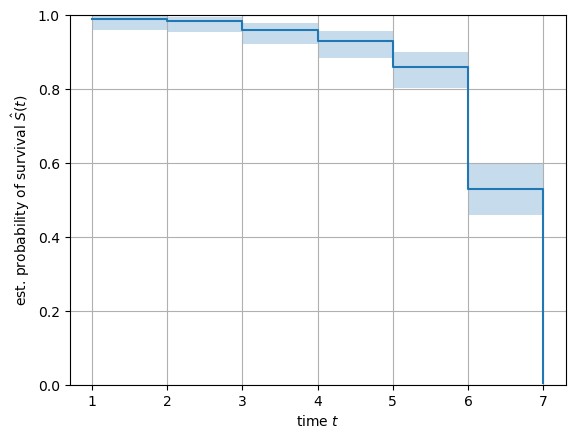

In [17]:
df_last_obs_time_split_subj = df_last_obs_time_split.loc[
    df_last_obs_time_split['g'] == g_max,:
]
time, survival_prob, conf_int = kaplan_meier_estimator(
    ~df_last_obs_time_split_subj["event_observed"], df_last_obs_time_split_subj["duration"], conf_type="log-log"
)

fig, ax = plt.subplots(1,1)
ax.step(time, survival_prob, where="post")
ax.grid()
plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.ylim(0, 1)
plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")

In [18]:
if split == 'test':
    obs_full_traj = ds_test._get_df_Xy_full_traj_obs(g0_as_gres=False)
elif split == 'val':
    obs_full_traj = ds_val._get_df_Xy_full_traj_obs(g0_as_gres=False)
else:
    raise NotImplementedError
obs_trans_time_all_g = get_all_grades_start_end_time(
    obs_full_traj.rename(columns={col_traj_id:'subject'}), 
    gs=gs
)

In [19]:
obs_trans_time_all_g

,subject,g,event_observed,t_observed_or_censored,t_uncensored_alive,missing_exact_t
0,E06000001SemiNew,0.01,True,1.0,0.0,True
1,E06000001SemiNew,0.02,True,3.0,2.0,True
2,E06000001SemiNew,0.03,True,4.0,3.0,True
3,E06000001SemiNew,0.04,True,4.0,3.0,True
4,E06000001SemiNew,0.05,True,4.0,3.0,True
...,...,...,...,...,...,...
95,W06000024TerracedExisting,0.96,False,7.0,NaN,False
96,W06000024TerracedExisting,0.97,False,7.0,NaN,False
97,W06000024TerracedExisting,0.98,False,7.0,NaN,False
98,W06000024TerracedExisting,0.99,False,7.0,NaN,False


In [20]:
obs_full_traj['duration'].max()

7.0

In [21]:
obs_trans_time_all_g

,subject,g,event_observed,t_observed_or_censored,t_uncensored_alive,missing_exact_t
0,E06000001SemiNew,0.01,True,1.0,0.0,True
1,E06000001SemiNew,0.02,True,3.0,2.0,True
2,E06000001SemiNew,0.03,True,4.0,3.0,True
3,E06000001SemiNew,0.04,True,4.0,3.0,True
4,E06000001SemiNew,0.05,True,4.0,3.0,True
...,...,...,...,...,...,...
95,W06000024TerracedExisting,0.96,False,7.0,NaN,False
96,W06000024TerracedExisting,0.97,False,7.0,NaN,False
97,W06000024TerracedExisting,0.98,False,7.0,NaN,False
98,W06000024TerracedExisting,0.99,False,7.0,NaN,False


In [22]:
obs_trans_time_all_g.groupby('g').apply(
    lambda x: pd.Series(
        [
            x.loc[
                x['event_observed'].astype(bool),
                't_observed_or_censored'
            ].max(),
            x.loc[
                ~x['event_observed'].astype(bool),
                't_observed_or_censored'
            ].max(),
            x['t_uncensored_alive'].max(),
        ],
        index=['t_observed', 'censored','t_uncensored_alive']
    )
)

/tmp/ipykernel_8832/1312802341.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  obs_trans_time_all_g.groupby('g').apply(


,t_observed,censored,t_uncensored_alive
g,,,
0.01,6.0,6.0,5.0
0.02,6.0,6.0,5.0
0.03,6.0,6.0,5.0
0.04,6.0,6.0,5.0
0.05,6.0,6.0,5.0
...,...,...,...
0.96,3.0,7.0,2.0
0.97,3.0,7.0,2.0
0.98,3.0,7.0,2.0


In [23]:
max_time = 7

In [24]:
obs_trans_time_all_g

,subject,g,event_observed,t_observed_or_censored,t_uncensored_alive,missing_exact_t
0,E06000001SemiNew,0.01,True,1.0,0.0,True
1,E06000001SemiNew,0.02,True,3.0,2.0,True
2,E06000001SemiNew,0.03,True,4.0,3.0,True
3,E06000001SemiNew,0.04,True,4.0,3.0,True
4,E06000001SemiNew,0.05,True,4.0,3.0,True
...,...,...,...,...,...,...
95,W06000024TerracedExisting,0.96,False,7.0,NaN,False
96,W06000024TerracedExisting,0.97,False,7.0,NaN,False
97,W06000024TerracedExisting,0.98,False,7.0,NaN,False
98,W06000024TerracedExisting,0.99,False,7.0,NaN,False


In [25]:
model_to_metric = []
model_to_prop_t_violated_per_subj = []
model_to_max_violated_per_subj = []
for run_id, pred_fun, descriptor in [

    ('7spytpix',pred_from_DeepHit,'LossSumo'),
    ('8hzklnu6',pred_from_DeepHit,'LossSumo'),
    ('f7foo960',pred_from_DeepHit,'LossSumo'),
    ('t7wgc97g',pred_from_DeepHit,'LossSumo'),
    ('uzcydgxn',pred_from_DeepHit,'LossSumo'),

    ('rllbuo0l',pred_from_DeepHit,'LossSumo(more g)'),
    ('x3n8mkuy',pred_from_DeepHit,'LossSumo(more g)'),
    ('kj9zyq9i',pred_from_DeepHit,'LossSumo(more g)'),
    ('ap6ndejn',pred_from_DeepHit,'LossSumo(more g)'),
    ('blcivfba',pred_from_DeepHit,'LossSumo(more g)'),
    
    ('t9eywte0',pred_from_DeepHit,'LossDyDg'),
    ('xqeevd7d',pred_from_DeepHit,'LossDyDg'),
    ('w0cthlye',pred_from_DeepHit,'LossDyDg'),
    ('5yjylgxt',pred_from_DeepHit,'LossDyDg'),
    ('wt9bwqow',pred_from_DeepHit,'LossDyDg'),

    ('qo8ic6dr',pred_from_SurvSurf,'LossDyDg'),
    ('5d0jw158',pred_from_SurvSurf,'LossDyDg'),
    ('i90mv1wx',pred_from_SurvSurf,'LossDyDg'),
    ('9gtyn4p7',pred_from_SurvSurf,'LossDyDg'),
    ('bd0l6nyo',pred_from_SurvSurf,'LossDyDg'),
        
    ('Joint_CoxnetSurvivalAnalysis_seed_10',pred_from_sksurv_joint, 'standard'),
    ('Joint_CoxPHSurvivalAnalysis_seed_10',pred_from_sksurv_joint, 'standard'),

    ('Joint_GradientBoostingSurvivalAnalysis_seed_10',pred_from_sksurv_joint, 'standard'),
    ('Joint_GradientBoostingSurvivalAnalysis_seed_20',pred_from_sksurv_joint, 'standard'),
    ('Joint_GradientBoostingSurvivalAnalysis_seed_30',pred_from_sksurv_joint, 'standard'),
    ('Joint_GradientBoostingSurvivalAnalysis_seed_40',pred_from_sksurv_joint, 'standard'),
    ('Joint_GradientBoostingSurvivalAnalysis_seed_50',pred_from_sksurv_joint, 'standard'),

    ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_10',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_20',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_30',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_40',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_50',pred_from_sksurv_joint, 'standard(more g)'),

    ('Joint_RandomSurvivalForest_seed_10',pred_from_sksurv_joint, 'standard'),
    ('Joint_RandomSurvivalForest_seed_20',pred_from_sksurv_joint, 'standard'),
    ('Joint_RandomSurvivalForest_seed_30',pred_from_sksurv_joint, 'standard'),
    ('Joint_RandomSurvivalForest_seed_40',pred_from_sksurv_joint, 'standard'),
    ('Joint_RandomSurvivalForest_seed_50',pred_from_sksurv_joint, 'standard'),
    
    ('Joint_RandomSurvivalForest_more_g_seed_10',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_RandomSurvivalForest_more_g_seed_20',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_RandomSurvivalForest_more_g_seed_30',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_RandomSurvivalForest_more_g_seed_40',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_RandomSurvivalForest_more_g_seed_50',pred_from_sksurv_joint, 'standard(more g)'),
]:
    out_model, model_name = pred_fun(run_id=run_id, proj_name=proj_name, split=split)


    intrg_brier_intrvl_imputed_ipcw_by_sbj = get_integrated_brier_intrvl_imputed(
        obs_trans_time_all_g, 
        out_model, 
        df_last_obs_time_split, 
        ipcw='by_subj', 
        max_time=max_time,
        max_grade=g_max
    )
    intrg_brier_intrvl_imputed = get_integrated_brier_intrvl_imputed(
        obs_trans_time_all_g, 
        out_model, 
        df_last_obs_time_split, 
        ipcw='without_ipcw', 
        max_time=max_time,
        max_grade=g_max
    )
    model_to_metric.append(
        {
            'run_id':run_id,
            'model_type':model_name,
            'intrg_brier_intrvl_imputed_ipcw_by_sbj':intrg_brier_intrvl_imputed_ipcw_by_sbj,
            'intrg_brier_intrvl_imputed':intrg_brier_intrvl_imputed,
            'descriptor':descriptor
        }
    )

    df = out_model['true_prob'].groupby(['subj','t']).apply(
        lambda x: (x.sort_values('g')['pred'].diff()> 0).any(),
        include_groups=False
    ).rename('any_violation').reset_index()
    df_fract_t_violated_per_subj = df.groupby('subj')['any_violation'].mean().reset_index()

    df = out_model['true_prob'].groupby(['subj','t']).apply(
        lambda x: (x.sort_values('g')['pred'].diff().max()),
        include_groups=False
    ).rename('max_violation').reset_index()
    df_fract_t_violated_per_subj['max_violation'] = df_fract_t_violated_per_subj['subj'].map(
        df.groupby('subj')['max_violation'].max()
    )
    row = df_fract_t_violated_per_subj['any_violation'].describe().to_dict()
    row['model_type'] = model_name.replace('Joint_','')
    row['run_id'] = run_id
    row['descriptor'] = descriptor
    model_to_prop_t_violated_per_subj.append(row)


    row = df_fract_t_violated_per_subj.loc[
        df_fract_t_violated_per_subj['any_violation'] > 0,
        'max_violation'
    ].describe().to_dict()
    row['model_type'] = model_name
    row['run_id'] = run_id
    model_to_max_violated_per_subj.append(row)
    print(f'finished processing {run_id}')

df_prop_t_violated_per_subj = pd.DataFrame(model_to_prop_t_violated_per_subj)
df_max_violated_per_subj = pd.DataFrame(model_to_max_violated_per_subj)
df_model_to_metric = pd.DataFrame(model_to_metric)
del model_to_prop_t_violated_per_subj
del model_to_max_violated_per_subj
del model_to_metric

/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:234: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps upd

finished processing 7spytpix


/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:234: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps upd

finished processing 8hzklnu6


/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:234: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps upd

...

finished processing Joint_RandomSurvivalForest_more_g_seed_30


/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:234: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  subj_last_obs_time_train[COLNAME_SURVIVAL_EVENT_OBSERVED].iloc[0] = True # otherwise CensoringDistributionEstimator in integrated_bri

finished processing Joint_RandomSurvivalForest_more_g_seed_40


/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:234: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  subj_last_obs_time_train[COLNAME_SURVIVAL_EVENT_OBSERVED].iloc[0] = True # otherwise CensoringDistributionEstimator in integrated_bri

finished processing Joint_RandomSurvivalForest_more_g_seed_50


In [26]:
df_model_to_metric['median_prop_t_violated'] = df_model_to_metric['run_id'].map(
    df_prop_t_violated_per_subj.set_index('run_id')['50%']
)
df_model_to_metric['median_max_violation'] = df_model_to_metric['run_id'].map(
    df_max_violated_per_subj.set_index('run_id')['50%']
)
df_model_to_metric['max_prop_t_violated'] = df_model_to_metric['run_id'].map(
    df_prop_t_violated_per_subj.set_index('run_id')['max']
)
df_model_to_metric['max_max_violation'] = df_model_to_metric['run_id'].map(
    df_max_violated_per_subj.set_index('run_id')['max']
)

In [27]:
df_model_to_metric.to_csv(f'./output_fig/{ds_name}_df_model_to_metric.csv')
df_model_to_metric

,run_id,model_type,intrg_brier_intrvl_imputed_ipcw_by_sbj,intrg_brier_intrvl_imputed,descriptor,median_prop_t_violated,median_max_violation,max_prop_t_violated,max_max_violation
0,7spytpix,DeepHit,0.293561,0.244224,LossSumo,0.285714,0.000001,0.571429,0.000004
1,8hzklnu6,DeepHit,0.292875,0.243741,LossSumo,0.285714,0.000001,0.571429,0.000004
2,f7foo960,DeepHit,0.293049,0.243880,LossSumo,0.285714,0.000001,0.571429,0.000003
3,t7wgc97g,DeepHit,0.293472,0.244191,LossSumo,0.285714,0.000002,0.571429,0.000004
4,uzcydgxn,DeepHit,0.294277,0.244744,LossSumo,0.285714,0.000001,0.571429,0.000004
5,rllbuo0l,DeepHit,0.170896,0.162073,LossSumo(more g),0.000000,NaN,0.000000,NaN
6,x3n8mkuy,DeepHit,0.166787,0.158168,LossSumo(more g),0.000000,NaN,0.000000,NaN
7,kj9zyq9i,DeepHit,0.168637,0.159895,LossSumo(more g),0.000000,NaN,0.000000,NaN
8,ap6ndejn,DeepHit,0.169631,0.160868,LossSumo(more g),0.000000,NaN,0.000000,NaN
9,blcivfba,DeepHit,0.169646,0.160848,LossSumo(more g),0.000000,NaN,0.000000,NaN


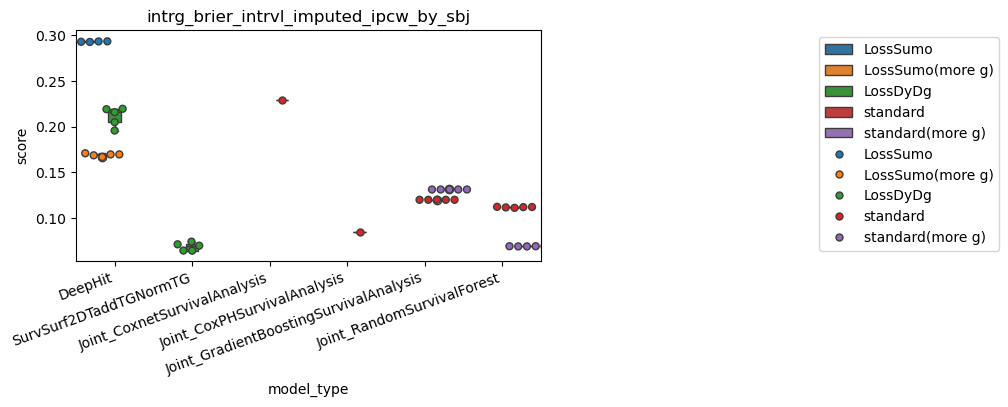

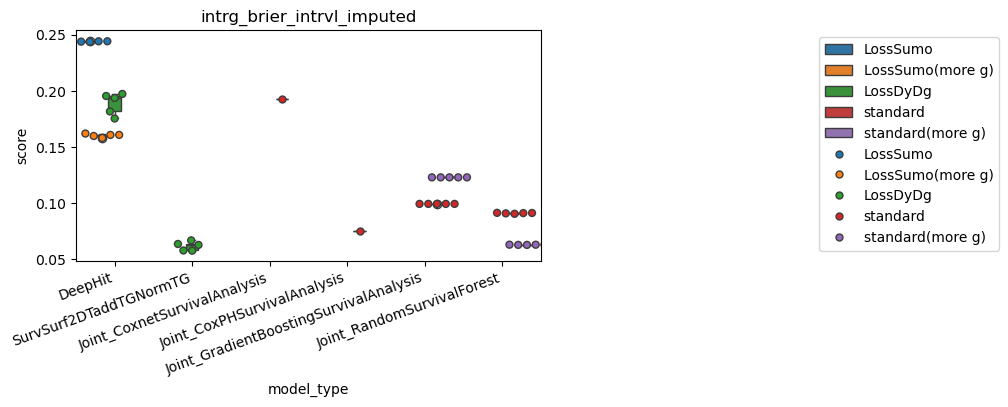

In [28]:
for y in (
    'intrg_brier_intrvl_imputed_ipcw_by_sbj',
    'intrg_brier_intrvl_imputed'
):
    fig, ax = plt.subplots(1,1, figsize=(6,3))
    sns.boxplot(
        data=df_model_to_metric,
        y=y,
        x='model_type',
        hue='descriptor',
        ax=ax
    )
    sns.swarmplot(
        data=df_model_to_metric,
        y=y,
        x='model_type',
        hue='descriptor',
        linewidth=1,
        dodge=True,
        ax=ax
    )
    ax.legend(bbox_to_anchor=(2, 1))
    ax.set(ylabel='score', title=y)

    plt.xticks(rotation=20, ha='right')

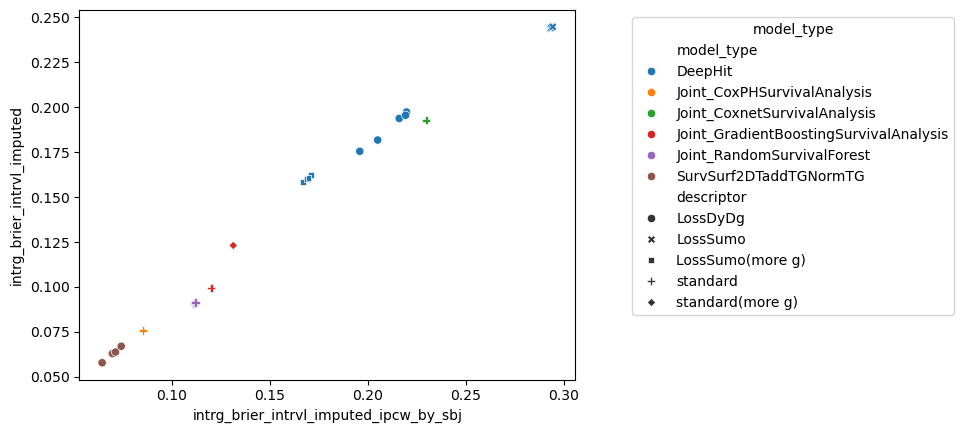

In [29]:
fig, ax = plt.subplots(1,1)

df = df_model_to_metric.copy()
df['max_max_violation'] = df['max_max_violation'].fillna(0)
df = df.sort_values(['model_type','descriptor'])
sns.scatterplot(
    data=df,
    x='intrg_brier_intrvl_imputed_ipcw_by_sbj',
    y='intrg_brier_intrvl_imputed',
    hue='model_type',
    style='descriptor',
    ax=ax,
)
ax.legend(bbox_to_anchor=(1.1, 1), title='model_type')

[Text(0.5, 0, 'maximum violation of monotinicity'),
 Text(0, 0.5, 'mean $IBS^{ipcw}_{iti}$ over events')]

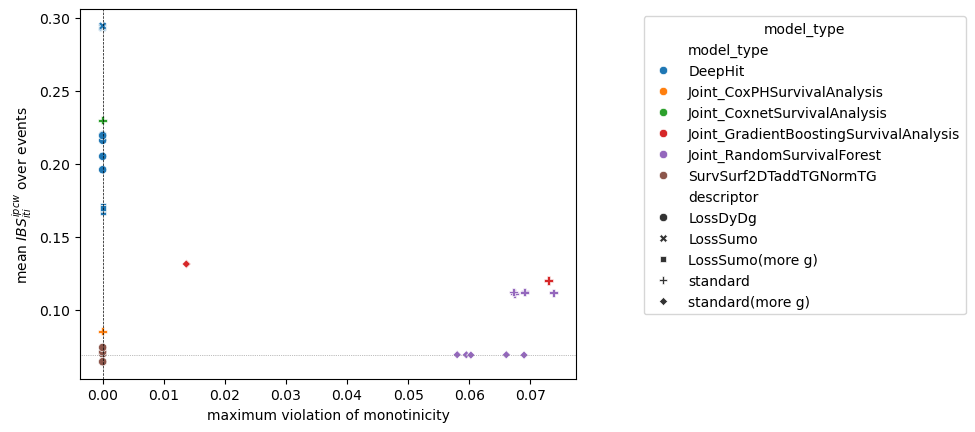

In [30]:
fig, ax = plt.subplots(1,1)
df = df_model_to_metric.copy()
df['max_max_violation'] = df['max_max_violation'].fillna(0)
df = df.sort_values(['model_type','descriptor'])
sns.scatterplot(
    data=df,
    x='max_max_violation',
    y='intrg_brier_intrvl_imputed_ipcw_by_sbj',
    hue='model_type',
    hue_order=sorted(df['model_type'].unique()),
    style='descriptor',
    ax=ax,
)

selector = (df['descriptor'] == 'LossDyDg') & (df['model_type'] == 'SurvSurf2DTaddTGNormTG')
mean_survsurf = df.loc[selector,'intrg_brier_intrvl_imputed_ipcw_by_sbj'].mean()
ax.axhline(y=mean_survsurf, ls=':', color='grey', lw=0.5)

selector = (df['descriptor'] == 'LossDyDgSumoFirstLast2') & (df['model_type'] == 'SurvSurf2DTaddTGNormTG')
mean_survsurf = df.loc[selector,'intrg_brier_intrvl_imputed_ipcw_by_sbj'].mean()
ax.axhline(y=mean_survsurf, ls='--', color='grey', lw=0.5)

ax.axvline(x=0, ls='--', color='black', lw=0.5)
ax.legend(bbox_to_anchor=(1.8, 1), title='model_type')
ax.set(xlabel='maximum violation of monotinicity', ylabel='mean $IBS^{ipcw}_{iti}$ over events')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '(SurvSurf2DTaddTGNormTG, LossDyDg)'),
  Text(1, 0, '(Joint_RandomSurvivalForest, standard(more g))'),
  Text(2, 0, '(Joint_CoxPHSurvivalAnalysis, standard)'),
  Text(3, 0, '(Joint_RandomSurvivalForest, standard)'),
  Text(4, 0, '(Joint_GradientBoostingSurvivalAnalysis, standard)'),
  Text(5, 0, '(Joint_GradientBoostingSurvivalAnalysis, standard(more g))'),
  Text(6, 0, '(DeepHit, LossSumo(more g))'),
  Text(7, 0, '(DeepHit, LossDyDg)'),
  Text(8, 0, '(Joint_CoxnetSurvivalAnalysis, standard)'),
  Text(9, 0, '(DeepHit, LossSumo)')])

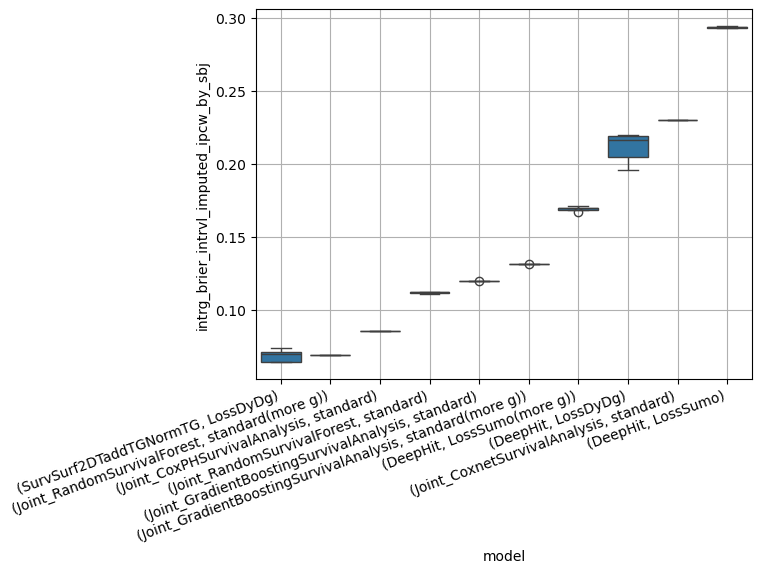

In [31]:
fig, ax = plt.subplots(1,1)
df = df_model_to_metric.copy()
df['max_max_violation'] = df['max_max_violation'].fillna(0)
df = df.sort_values(['model_type','descriptor'])
df['model'] = '(' + df['model_type'] + ', ' + df['descriptor'] + ')'

df['mean_score'] = df['model'].map(df.groupby('model')['intrg_brier_intrvl_imputed_ipcw_by_sbj'].mean().to_dict())
df = df.sort_values('mean_score')
sns.boxplot(
    data=df,
    x='model',
    y='intrg_brier_intrvl_imputed_ipcw_by_sbj',
    ax=ax,
)

ax.set(ylabel='intrg_brier_intrvl_imputed_ipcw_by_sbj')
plt.grid()
plt.xticks(rotation=20, ha='right')

In [32]:
df_model_to_metric.groupby(['model_type','descriptor'])['intrg_brier_intrvl_imputed_ipcw_by_sbj'].describe()

count      mean  \
model_type                             descriptor                          
DeepHit                                LossDyDg            5.0  0.211093   
                                       LossSumo            5.0  0.293447   
                                       LossSumo(more g)    5.0  0.169119   
Joint_CoxPHSurvivalAnalysis            standard            1.0  0.085127   
Joint_CoxnetSurvivalAnalysis           standard            1.0  0.229735   
Joint_GradientBoostingSurvivalAnalysis standard            5.0  0.119923   
                                       standard(more g)    5.0  0.131195   
Joint_RandomSurvivalForest             standard            5.0  0.111737   
                                       standard(more g)    5.0  0.068962   
SurvSurf2DTaddTGNormTG                 LossDyDg            5.0  0.068647   

                                                                  std  \
model_type                             descriptor                       
DeepHit                                LossDyDg          1.041627e-02   
                                       LossSumo          5.451917e-04   
                                       LossSumo(more g)  1.530536e-03   
Joint_CoxPHSurvivalAnalysis            standard                   NaN   
Joint_CoxnetSurvivalAnalysis           standard                   NaN   
Joint_GradientBoostingSurvivalAnalysis standard          2.081668e-17   
                                       standard(more g)  4.388542e-17   
Joint_RandomSurvivalForest             standard          4.364458e-04   
                                       standard(more g)  1.107739e-04   
SurvSurf2DTaddTGNormTG                 LossDyDg          4.341488e-03   

                                                              min       25%  \
model_type                             descriptor                             
DeepHit                                LossDyDg          0.195787  0.204932   
                                       LossSumo          0.292875  0.293049   
                                       LossSumo(more g)  0.166787  0.168637   
Joint_CoxPHSurvivalAnalysis            standard          0.085127  0.085127   
Joint_CoxnetSurvivalAnalysis           standard          0.229735  0.229735   
Joint_GradientBoostingSurvivalAnalysis standard          0.119923  0.119923   
                                       standard(more g)  0.131195  0.131195   
Joint_RandomSurvivalForest             standard          0.111083  0.111544   
                                       standard(more g)  0.068838  0.068845   
SurvSurf2DTaddTGNormTG                 LossDyDg          0.064144  0.064298   

                                                              50%       75%  \
model_type                             descriptor                             
DeepHit                                LossDyDg          0.215932  0.219176   
                                       LossSumo          0.293472  0.293561   
                                       LossSumo(more g)  0.169631  0.169646   
Joint_CoxPHSurvivalAnalysis            standard          0.085127  0.085127   
Joint_CoxnetSurvivalAnalysis           standard          0.229735  0.229735   
Joint_GradientBoostingSurvivalAnalysis standard          0.119923  0.119923   
                                       standard(more g)  0.131195  0.131195   
Joint_RandomSurvivalForest             standard          0.111859  0.112005   
                                       standard(more g)  0.069021  0.069036   
SurvSurf2DTaddTGNormTG                 LossDyDg          0.069624  0.071129   

                                                              max  
model_type                             descriptor                  
DeepHit                                LossDyDg          0.219637  
                                       LossSumo          0.294277  
                                       LossSumo(more g)  0.170896  
Joint_CoxPHSurvivalAnalysis  

In [33]:
df_model_to_metric.groupby(['model_type','descriptor'])['intrg_brier_intrvl_imputed'].describe()

count      mean  \
model_type                             descriptor                          
DeepHit                                LossDyDg            5.0  0.188758   
                                       LossSumo            5.0  0.244156   
                                       LossSumo(more g)    5.0  0.160371   
Joint_CoxPHSurvivalAnalysis            standard            1.0  0.075673   
Joint_CoxnetSurvivalAnalysis           standard            1.0  0.192780   
Joint_GradientBoostingSurvivalAnalysis standard            5.0  0.099442   
                                       standard(more g)    5.0  0.123065   
Joint_RandomSurvivalForest             standard            5.0  0.091147   
                                       standard(more g)    5.0  0.063060   
SurvSurf2DTaddTGNormTG                 LossDyDg            5.0  0.061888   

                                                                  std  \
model_type                             descriptor                       
DeepHit                                LossDyDg          9.619385e-03   
                                       LossSumo          3.873360e-04   
                                       LossSumo(more g)  1.453631e-03   
Joint_CoxPHSurvivalAnalysis            standard                   NaN   
Joint_CoxnetSurvivalAnalysis           standard                   NaN   
Joint_GradientBoostingSurvivalAnalysis standard          1.387779e-17   
                                       standard(more g)  4.955361e-17   
Joint_RandomSurvivalForest             standard          3.323571e-04   
                                       standard(more g)  1.037135e-04   
SurvSurf2DTaddTGNormTG                 LossDyDg          3.955744e-03   

                                                              min       25%  \
model_type                             descriptor                             
DeepHit                                LossDyDg          0.175474  0.181719   
                                       LossSumo          0.243741  0.243880   
                                       LossSumo(more g)  0.158168  0.159895   
Joint_CoxPHSurvivalAnalysis            standard          0.075673  0.075673   
Joint_CoxnetSurvivalAnalysis           standard          0.192780  0.192780   
Joint_GradientBoostingSurvivalAnalysis standard          0.099442  0.099442   
                                       standard(more g)  0.123065  0.123065   
Joint_RandomSurvivalForest             standard          0.090647  0.091006   
                                       standard(more g)  0.062946  0.062953   
SurvSurf2DTaddTGNormTG                 LossDyDg          0.057796  0.057976   

                                                              50%       75%  \
model_type                             descriptor                             
DeepHit                                LossDyDg          0.193751  0.195517   
                                       LossSumo          0.244191  0.244224   
                                       LossSumo(more g)  0.160848  0.160868   
Joint_CoxPHSurvivalAnalysis            standard          0.075673  0.075673   
Joint_CoxnetSurvivalAnalysis           standard          0.192780  0.192780   
Joint_GradientBoostingSurvivalAnalysis standard          0.099442  0.099442   
                                       standard(more g)  0.123065  0.123065   
Joint_RandomSurvivalForest             standard          0.091234  0.091356   
                                       standard(more g)  0.063102  0.063134   
SurvSurf2DTaddTGNormTG                 LossDyDg          0.062918  0.063770   

                                                              max  
model_type                             descriptor                  
DeepHit                                LossDyDg          0.197331  
                                       LossSumo          0.244744  
                                       LossSumo(more g)  0.162073  
Joint_CoxPHSurvivalAnalysis  

In [34]:
df_model_to_metric.groupby(['model_type','descriptor'])['max_max_violation'].describe()

count      mean  \
model_type                             descriptor                          
DeepHit                                LossDyDg            0.0       NaN   
                                       LossSumo            5.0  0.000004   
                                       LossSumo(more g)    0.0       NaN   
Joint_CoxPHSurvivalAnalysis            standard            0.0       NaN   
Joint_CoxnetSurvivalAnalysis           standard            0.0       NaN   
Joint_GradientBoostingSurvivalAnalysis standard            5.0  0.072965   
                                       standard(more g)    5.0  0.013687   
Joint_RandomSurvivalForest             standard            5.0  0.069328   
                                       standard(more g)    5.0  0.062569   
SurvSurf2DTaddTGNormTG                 LossDyDg            0.0       NaN   

                                                                  std  \
model_type                             descriptor                       
DeepHit                                LossDyDg                   NaN   
                                       LossSumo          3.433093e-07   
                                       LossSumo(more g)           NaN   
Joint_CoxPHSurvivalAnalysis            standard                   NaN   
Joint_CoxnetSurvivalAnalysis           standard                   NaN   
Joint_GradientBoostingSurvivalAnalysis standard          5.003708e-17   
                                       standard(more g)  4.965220e-17   
Joint_RandomSurvivalForest             standard          2.651814e-03   
                                       standard(more g)  4.700436e-03   
SurvSurf2DTaddTGNormTG                 LossDyDg                   NaN   

                                                              min       25%  \
model_type                             descriptor                             
DeepHit                                LossDyDg               NaN       NaN   
                                       LossSumo          0.000003  0.000004   
                                       LossSumo(more g)       NaN       NaN   
Joint_CoxPHSurvivalAnalysis            standard               NaN       NaN   
Joint_CoxnetSurvivalAnalysis           standard               NaN       NaN   
Joint_GradientBoostingSurvivalAnalysis standard          0.072965  0.072965   
                                       standard(more g)  0.013687  0.013687   
Joint_RandomSurvivalForest             standard          0.067267  0.067383   
                                       standard(more g)  0.058023  0.059525   
SurvSurf2DTaddTGNormTG                 LossDyDg               NaN       NaN   

                                                              50%       75%  \
model_type                             descriptor                             
DeepHit                                LossDyDg               NaN       NaN   
                                       LossSumo          0.000004  0.000004   
                                       LossSumo(more g)       NaN       NaN   
Joint_CoxPHSurvivalAnalysis            standard               NaN       NaN   
Joint_CoxnetSurvivalAnalysis           standard               NaN       NaN   
Joint_GradientBoostingSurvivalAnalysis standard          0.072965  0.072965   
                                       standard(more g)  0.013687  0.013687   
Joint_RandomSurvivalForest             standard          0.069067  0.069125   
                                       standard(more g)  0.060267  0.066063   
SurvSurf2DTaddTGNormTG                 LossDyDg               NaN       NaN   

                                                              max  
model_type                             descriptor                  
DeepHit                                LossDyDg               NaN  
                                       LossSumo          0.000004  
                                       LossSumo(more g)       NaN  
Joint_CoxPHSurvivalAnalysis  

In [35]:
df_model_to_metric.groupby(['model_type','descriptor'])['max_prop_t_violated'].describe()

count      mean  std  \
model_type                             descriptor                               
DeepHit                                LossDyDg            5.0  0.000000  0.0   
                                       LossSumo            5.0  0.571429  0.0   
                                       LossSumo(more g)    5.0  0.000000  0.0   
Joint_CoxPHSurvivalAnalysis            standard            1.0  0.000000  NaN   
Joint_CoxnetSurvivalAnalysis           standard            1.0  0.000000  NaN   
Joint_GradientBoostingSurvivalAnalysis standard            5.0  1.000000  0.0   
                                       standard(more g)    5.0  1.000000  0.0   
Joint_RandomSurvivalForest             standard            5.0  1.000000  0.0   
                                       standard(more g)    5.0  1.000000  0.0   
SurvSurf2DTaddTGNormTG                 LossDyDg            5.0  0.000000  0.0   

                                                              min       25%  \
model_type                             descriptor                             
DeepHit                                LossDyDg          0.000000  0.000000   
                                       LossSumo          0.571429  0.571429   
                                       LossSumo(more g)  0.000000  0.000000   
Joint_CoxPHSurvivalAnalysis            standard          0.000000  0.000000   
Joint_CoxnetSurvivalAnalysis           standard          0.000000  0.000000   
Joint_GradientBoostingSurvivalAnalysis standard          1.000000  1.000000   
                                       standard(more g)  1.000000  1.000000   
Joint_RandomSurvivalForest             standard          1.000000  1.000000   
                                       standard(more g)  1.000000  1.000000   
SurvSurf2DTaddTGNormTG                 LossDyDg          0.000000  0.000000   

                                                              50%       75%  \
model_type                             descriptor                             
DeepHit                                LossDyDg          0.000000  0.000000   
                                       LossSumo          0.571429  0.571429   
                                       LossSumo(more g)  0.000000  0.000000   
Joint_CoxPHSurvivalAnalysis            standard          0.000000  0.000000   
Joint_CoxnetSurvivalAnalysis           standard          0.000000  0.000000   
Joint_GradientBoostingSurvivalAnalysis standard          1.000000  1.000000   
                                       standard(more g)  1.000000  1.000000   
Joint_RandomSurvivalForest             standard          1.000000  1.000000   
                                       standard(more g)  1.000000  1.000000   
SurvSurf2DTaddTGNormTG                 LossDyDg          0.000000  0.000000   

                                                              max  
model_type                             descriptor                  
DeepHit                                LossDyDg          0.000000  
                                       LossSumo          0.571429  
                                       LossSumo(more g)  0.000000  
Joint_CoxPHSurvivalAnalysis            standard          0.000000  
Joint_CoxnetSurvivalAnalysis           standard          0.000000  
Joint_GradientBoostingSurvivalAnalysis standard          1.000000  
                                       standard(more g)  1.000000  
Joint_RandomSurvivalForest             standard          1.000000  
                                       standard(more g)  1.000000  
SurvSurf2DTaddTGNormTG                 LossDyDg          0.000000

# Clean up

In [36]:
with torch.no_grad():
    torch.cuda.empty_cache()
gc.collect()

1644